<a href="https://colab.research.google.com/github/Ismot10/Disaster-Management-and-Early-Warning-System-App/blob/main/EARTHQUAKE_LSTM_(binary_model).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## CELL 1 — Install & Import Libraries


# ==============================
# 📦 Install required libraries
# ==============================
!pip install pandas numpy matplotlib scikit-learn tensorflow seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
## CELL 2 — Upload Earthquake Dataset

from google.colab import files
uploaded = files.upload()


Saving earthquake_dataset.csv to earthquake_dataset (1).csv


In [ ]:
## CELL 3 — Load & Inspect Data

df = pd.read_csv("earthquake_dataset.csv")

# Convert timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df.dropna(subset=['timestamp'])

# Sort for time-series (CRITICAL)
df = df.sort_values('timestamp')

df.tail()


,timestamp,motion,vibration_detected,earthquake_detected,risk_level
143,2026-01-27 21:16:18,0.003,No,No,Low
144,2026-01-27 21:16:22,0.005,No,No,Low
145,2026-01-27 21:16:27,0.007,No,No,Low
146,2026-01-27 21:16:32,0.011,No,No,Low
147,2026-01-27 21:16:37,0.008,No,No,Low


In [ ]:
## CELL 4 — Encode Labels & Select Features
# Encode earthquake detection (Yes / No) as 1 / 0

# Encode Yes / No to 1 / 0
df['vibration_detected'] = df['vibration_detected'].map({'Yes':1, 'No':0})
df['earthquake_detected'] = df['earthquake_detected'].map({'Yes':1, 'No':0})

features = [
    'motion',
    'vibration_detected'
]

X_data = df[features]
y_data = df['earthquake_detected']

X_data.describe()


,motion,vibration_detected
count,142.000000,142.0
mean,0.026458,0.0
std,0.156776,0.0
min,0.001000,0.0
25%,0.006000,0.0
50%,0.007000,0.0
75%,0.010000,0.0
max,1.621000,0.0


In [ ]:
## CELL 5 — Normalize Features

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_data)


In [ ]:
## CELL 6 — Create Time-Series Sequences (LSTM Input)

SEQUENCE_LENGTH = 15   # ~45 seconds (ESP32 delay=3s)

X = []
y = []

for i in range(SEQUENCE_LENGTH, len(X_scaled)):
    X.append(X_scaled[i-SEQUENCE_LENGTH:i])
    y.append(y_data.iloc[i])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (127, 15, 2)
y shape: (127,)


In [ ]:
## CELL 7 — Train / Test Split (NO SHUFFLE)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)


In [ ]:
## CELL 8 — Build LSTM Classification Model
# Build LSTM Model for EARTHQUAKE DETECTION


model = Sequential([
    LSTM(
        32,
        input_shape=(X.shape[1], X.shape[2]),
        return_sequences=False,
        unroll=True
    ),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,513 (17.63 KB)

 Trainable params: 4,513 (17.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
## CELL 9 — Train Model

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)


Epoch 1/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 401ms/step - accuracy: 1.0000 - loss: 0.6880 - val_accuracy: 1.0000 - val_loss: 0.6743
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 1.0000 - loss: 0.6674 - val_accuracy: 1.0000 - val_loss: 0.6520
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 1.0000 - loss: 0.6421 - val_accuracy: 1.0000 - val_loss: 0.6227
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 1.0000 - loss: 0.6128 - val_accuracy: 1.0000 - val_loss: 0.5822
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 1.0000 - loss: 0.5654 - val_accuracy: 1.0000 - val_loss: 0.5236
Epoch 6/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 1.0000 - loss: 0.5017 - val_accuracy: 1.0000 - val_loss: 0.4362
Epoch 7/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 1.0000 - loss: 0.4099 - val_accuracy: 1.0000 - val_loss: 0.3075
Epoch 8/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 1.0000 - loss: 0.2723 - val_accuracy: 1.0000 - val_loss: 0.148

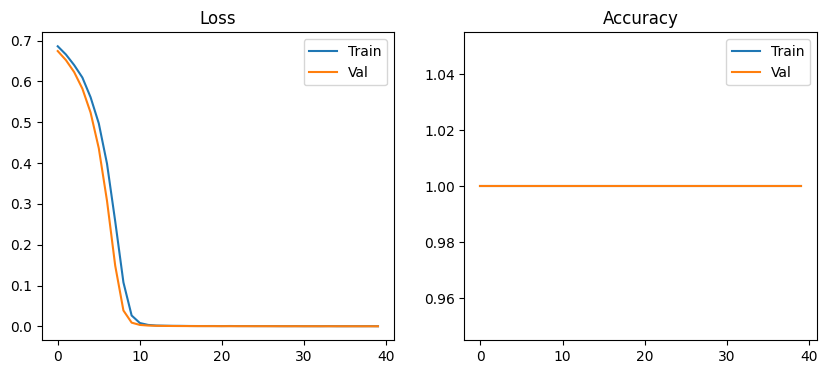

In [ ]:
## CELL 10 — Training Loss & Accuracy Plot

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')

plt.title("Detection Loss")

plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Detection Accuracy")
plt.legend()

plt.show()


In [ ]:
## CELL 11 — Predictions

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 900ms/step


In [ ]:
## CELL 12 — ✅ Accuracy Score

acc = accuracy_score(y_test, y_pred)
print("✅ Earthquake Detection Accuracy:", round(acc * 100, 2), "%")


✅ Accuracy: 100.0 %


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


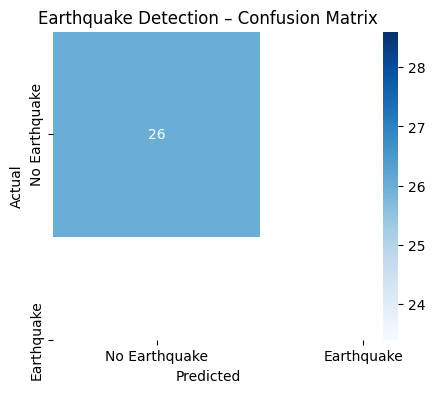

In [ ]:
## CELL 13 — 📈 Confusion Matrix (VISUAL)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Earthquake", "Earthquake"],
    yticklabels=["No Earthquake", "Earthquake"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Earthquake Detection – Confusion Matrix")
plt.show()


In [ ]:
## CELL 14 — Classification Report

from sklearn.metrics import classification_report

print("Earthquake Detection Classification Report")
print(classification_report(
    y_test,
    y_pred,
    labels=[0,1],
    target_names=["No Earthquake", "Earthquake"],
    zero_division=0   # avoids division by zero warnings
))


               precision    recall  f1-score   support

No Earthquake       1.00      1.00      1.00        26
   Earthquake       0.00      0.00      0.00         0

     accuracy                           1.00        26
    macro avg       0.50      0.50      0.50        26
 weighted avg       1.00      1.00      1.00        26



In [ ]:
## CELL 15 — Save Model

model.save("earthquake_detection_lstm_model.keras")
print("✅ Earthquake Detection LSTM model saved")


✅ Earthquake LSTM model saved


In [ ]:
## CELL 16 — Convert to PURE TFLite (Flutter Compatible)

import tensorflow as tf

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS
]

converter._experimental_lower_tensor_list_ops = True
converter.experimental_enable_resource_variables = False
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open("earthquake_lstm_model.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ Earthquake Detection TFLite model created")

Saved artifact at '/tmp/tmpl_hjiw5q'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 15, 2), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139219824692880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139219824691344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139219824698448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139219824694032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139219824691920: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ Earthquake TFLite model created


In [ ]:
## CELL 17 — Download TFLite Model

from google.colab import files
files.download("earthquake_lstm_model.tflite")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>